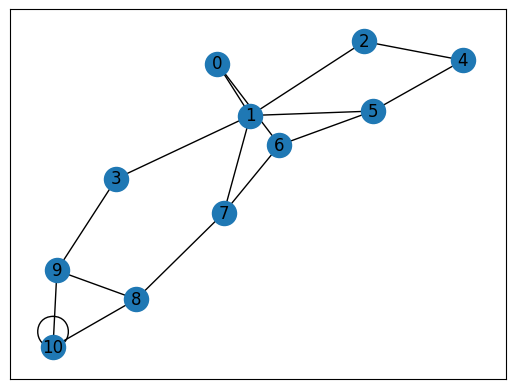

In [8]:
import numpy as np
import pylab as pl
import networkx as nx
edges = [(0, 1), (1, 5), (5, 6), (5, 4), (1, 2),
    (1, 3), (9, 10), (2, 4), (0, 6), (6, 7),
    (8, 9), (7, 8), (1, 7), (3, 9),(10,8),(10,10)]

goal = 10
G = nx.Graph()
G.add_edges_from(edges)
pos = nx.spring_layout(G)
nx.draw_networkx_nodes(G, pos)
nx.draw_networkx_edges(G, pos)
nx.draw_networkx_labels(G, pos)
pl.show()
MATRIX_SIZE = 11
R = np.matrix(np.ones(shape =(MATRIX_SIZE, MATRIX_SIZE)))
R *= -1


In [10]:

for point in edges:
  print(point)
  if point[1] == goal: #GOAL IS 10
    R[point] = 100
  else:
    R[point] = 0

  if point[0] == goal:
    R[point[::-1]] = 100 #SEQUENCE [START: STOP: STEP] shows the output in reverse order.  (9->10) gets reward but (10,9) doesn't
  else:
    R[point[::-1]]= 0  #REVERSE ALSO SAME POINT AS O
    # reverse of point


(0, 1)
(1, 5)
(5, 6)
(5, 4)
(1, 2)
(1, 3)
(9, 10)
(2, 4)
(0, 6)
(6, 7)
(8, 9)
(7, 8)
(1, 7)
(3, 9)
(10, 8)
(10, 10)


In [11]:

R[goal, goal]= 100
print(R)
# add goal point round trip
Q = np.matrix(np.zeros([MATRIX_SIZE, MATRIX_SIZE]))

gamma = 0.75
# learning parameter
initial_state = 1


[[ -1.   0.  -1.  -1.  -1.  -1.   0.  -1.  -1.  -1.  -1.]
 [  0.  -1.   0.   0.  -1.   0.  -1.   0.  -1.  -1.  -1.]
 [ -1.   0.  -1.  -1.   0.  -1.  -1.  -1.  -1.  -1.  -1.]
 [ -1.   0.  -1.  -1.  -1.  -1.  -1.  -1.  -1.   0.  -1.]
 [ -1.  -1.   0.  -1.  -1.   0.  -1.  -1.  -1.  -1.  -1.]
 [ -1.   0.  -1.  -1.   0.  -1.   0.  -1.  -1.  -1.  -1.]
 [  0.  -1.  -1.  -1.  -1.   0.  -1.   0.  -1.  -1.  -1.]
 [ -1.   0.  -1.  -1.  -1.  -1.   0.  -1.   0.  -1.  -1.]
 [ -1.  -1.  -1.  -1.  -1.  -1.  -1.   0.  -1.   0. 100.]
 [ -1.  -1.  -1.   0.  -1.  -1.  -1.  -1.   0.  -1. 100.]
 [ -1.  -1.  -1.  -1.  -1.  -1.  -1.  -1.   0.   0. 100.]]


In [25]:

# Determines the available actions for a given state
def available_actions(state):
  current_state_row = R[state, ]
  available_action = np.where(current_state_row >= 0)[1]
  return available_action

available_action = available_actions(initial_state)
print("available actions: ", available_action)
# Chooses one of the available actions at random
def sample_next_action(available_actions_range):
  next_action = int(np.random.choice(available_action, 1))
  return next_action


action = sample_next_action(available_action)
print("next actions: ", action)


available actions:  [0 2 3 5 7]
next actions:  7


/tmp/ipykernel_537/3358837492.py:11: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  next_action = int(np.random.choice(available_action, 1))


In [27]:

def update(current_state, action, gamma):
  max_index = np.where(Q[action, ] == np.max(Q[action, ]))[1]
  if max_index.shape[0] > 1:
    print("max_index: ",max_index)
    max_index = int(np.random.choice(max_index, size = 1)) #it will give output in aarray format
  else:
    print("max_index: ",max_index)
    max_index = int(max_index)  #It will be in the array format
  max_value = Q[action, max_index]
  Q[current_state, action] = R[current_state, action] + gamma * max_value
  if (np.max(Q) > 0):
    return(np.sum(Q / np.max(Q)*100))
  else:
   return (0)
# Updates the Q-Matrix according to the path chosen
print("Before Q matrix: ")
print(Q)
update(initial_state, action, gamma)
print("After Q matrix: ")
print(Q)
scores = []

Before Q matrix: 
[[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]
max_index:  [ 0  1  2  3  4  5  6  7  8  9 10]
After Q matrix: 
[[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]


/tmp/ipykernel_537/2377786942.py:5: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  max_index = int(np.random.choice(max_index, size = 1)) #it will give output in aarray format


In [28]:

for i in range(1000):
  current_state = np.random.randint(0, int(Q.shape[0]))
  available_action = available_actions(current_state)
  action = sample_next_action(available_action)
  score = update(current_state, action, gamma)
  scores.append(score)

print("Trained Q matrix:")
print(Q / np.max(Q)*100)
# You can uncomment the above two lines to view the trained Q matrix


max_index:  [ 0  1  2  3  4  5  6  7  8  9 10]
max_index:  [ 0  1  2  3  4  5  6  7  8  9 10]
max_index:  [ 0  1  2  3  4  5  6  7  8  9 10]
max_index:  [ 0  1  2  3  4  5  6  7  8  9 10]
max_index:  [ 0  1  2  3  4  5  6  7  8  9 10]
max_index:  [ 0  1  2  3  4  5  6  7  8  9 10]
max_index:  [ 0  1  2  3  4  5  6  7  8  9 10]
max_index:  [ 0  1  2  3  4  5  6  7  8  9 10]
max_index:  [ 0  1  2  3  4  5  6  7  8  9 10]
max_index:  [ 0  1  2  3  4  5  6  7  8  9 10]
max_index:  [ 0  1  2  3  4  5  6  7  8  9 10]
max_index:  [ 0  1  2  3  4  5  6  7  8  9 10]
max_index:  [ 0  1  2  3  4  5  6  7  8  9 10]
max_index:  [ 0  1  2  3  4  5  6  7  8  9 10]
max_index:  [ 0  1  2  3  4  5  6  7  8  9 10]
max_index:  [ 0  1  2  3  4  5  6  7  8  9 10]
max_index:  [ 0  1  2  3  4  5  6  7  8  9 10]
max_index:  [ 0  1  2  3  4  5  6  7  8  9 10]
max_index:  [ 0  1  2  3  4  5  6  7  8  9 10]
max_index:  [ 0  1  2  3  4  5  6  7  8  9 10]
max_index:  [ 0  1  2  3  4  5  6  7  8  9 10]
max_index:  [

/tmp/ipykernel_537/3358837492.py:11: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  next_action = int(np.random.choice(available_action, 1))
/tmp/ipykernel_537/2377786942.py:5: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  max_index = int(np.random.choice(max_index, size = 1)) #it will give output in aarray format
/tmp/ipykernel_537/2377786942.py:8: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  max_index = int(max_index)  #It will be in the array format


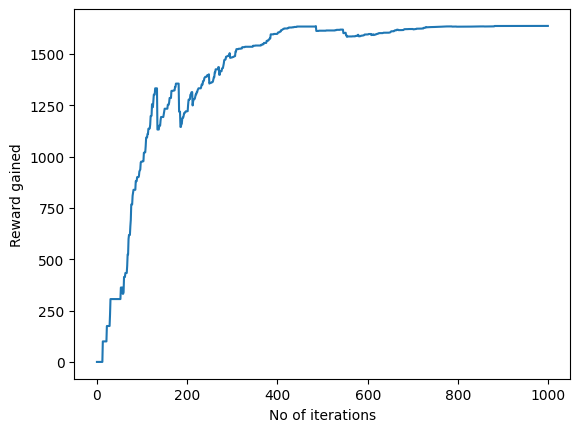

In [29]:

pl.plot(scores)
pl.xlabel('No of iterations')
pl.ylabel('Reward gained')
pl.show()
current_state = 2
steps = [current_state]


In [30]:

while current_state != 10:

  next_step_index = np.where(Q[current_state, ] == np.max(Q[current_state, ]))[1]
  if next_step_index.shape[0] > 1:
    next_step_index = int(np.random.choice(next_step_index, size = 1))
  else:
    next_step_index = int(next_step_index)
  steps.append(next_step_index)
  current_state = next_step_index

print("Most efficient path:")
print(steps)

Most efficient path:
[2, 1, 3, 9, 10]


/tmp/ipykernel_537/1970188110.py:7: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  next_step_index = int(next_step_index)
